### baseline_03_V2: Rerunning previous burn rate baseline using standard OLS format
- As with original baseline_03, this model is using three hard features: bullet mass, amount of propellant, and burn rate index of propellants

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("308_baseline_data.csv")
df.head()

,cartridge,bullet_diameter,bullet_brand,bullet_type,bullet_weight,powder_type,burn_rate_index,charge_weight,velocity_fps,barrel_length,data_source,primer,twist_rate,coal
0,308_win,0.308,lapua,als,57.0,vihtavuori_n110,64,27.5,3481,24.0,vihtavuori,large_rifle_generic,12.0,2.638
1,308_win,0.308,lapua,g589_ot,100.0,vihtavuori_n120,81,33.6,2890,24.0,vihtavuori,large_rifle_generic,12.0,2.638
2,308_win,0.308,lapua,g589_ot,100.0,vihtavuori_n130,84,37.8,2986,24.0,vihtavuori,large_rifle_generic,12.0,2.638
3,308_win,0.308,lapua,g589_ot,100.0,vihtavuori_n133,89,41.7,3097,24.0,vihtavuori,large_rifle_generic,12.0,2.638
4,308_win,0.308,lapua,g589_ot,100.0,vihtavuori_n135,102,43.2,3123,24.0,vihtavuori,large_rifle_generic,12.0,2.638


In [6]:
features = ["charge_weight", "bullet_weight", "burn_rate_index"]
target = "velocity_fps"

X = df[features].astype(float)
y = df[target].astype(float)

# Sanity checks
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1252, 3)
y shape: (1252,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (1001, 3)  Test: (251, 3)


In [12]:
mean_pred = np.full(shape=y_test.shape, fill_value=y_train.mean())
floor_mae = mean_absolute_error(y_test, mean_pred)

print(f"FLOOR MAE: {floor_mae:.2f}ft/s")

model = LinearRegression()
model.fit(X_train, y_train)

preds = model.predict(X_test)

model_mae = mean_absolute_error(y_test, preds)
print(f"MODEL MAE (test): {model_mae:.2f}ft/s")

FLOOR MAE: 190.84ft/s
MODEL MAE (test): 51.19ft/s


Intercept: 2277.2072852895885


charge_weight      45.550619
burn_rate_index    -6.681312
bullet_weight      -5.250062
dtype: float64

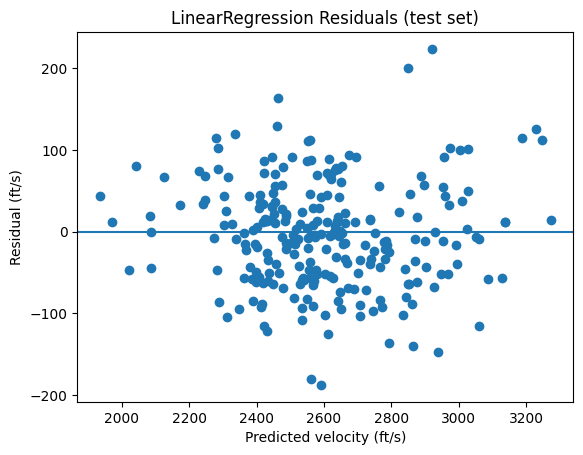

In [13]:
coefs = pd.Series(model.coef_.ravel(), index=features).sort_values(key=np.abs, ascending=False)
intercept = model.intercept_

print("Intercept:", intercept)
display(coefs)

residuals = y_test.to_numpy() - preds

plt.scatter(preds, residuals)
plt.axhline(0)
plt.xlabel("Predicted velocity (ft/s)")
plt.ylabel("Residual (ft/s)")
plt.title("LinearRegression Residuals (test set)")
plt.show()

### As with baseline_03 (first version), model is showing significant improvements in absolute error over models with less trained features
- Residuals are still behaving optimally with no discernable structure and centered near zero with no obvious bias